In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
test=pd.read_csv('/content/test.csv')
train=pd.read_csv('/content/train.csv')
test

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
11589,605583,45370.06,0.257,634,4304.31,15.90,Female,Single,Master's,Employed,Debt consolidation,D1
11590,605584,35156.98,0.206,726,14230.18,10.53,Female,Married,Other,Unemployed,Car,C4
11591,605585,33226.85,0.168,672,13200.50,11.13,Female,Single,Other,Employed,Debt consolidation,C5
11592,605586,93301.13,0.146,719,11231.14,9.67,Male,Single,Bachelor's,Employed,Car,C3


In [5]:
train

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11321,11321,79712.29,0.049,615,11976.29,11.82,Female,Single,Bachelor's,Employed,Other,D5,1.0
11322,11322,43157.20,0.116,715,23410.69,8.78,Female,Married,High School,Employed,Debt consolidation,C1,1.0
11323,11323,25280.84,0.120,594,15272.44,15.55,Female,Married,High School,Unemployed,Other,E4,0.0
11324,11324,52648.71,0.144,764,2975.72,12.45,Female,Single,High School,Employed,Debt consolidation,B4,1.0


In [6]:
#preprocessing
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11326 entries, 0 to 11325
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    11326 non-null  int64  
 1   annual_income         11326 non-null  float64
 2   debt_to_income_ratio  11326 non-null  float64
 3   credit_score          11326 non-null  int64  
 4   loan_amount           11326 non-null  float64
 5   interest_rate         11326 non-null  float64
 6   gender                11326 non-null  object 
 7   marital_status        11326 non-null  object 
 8   education_level       11326 non-null  object 
 9   employment_status     11326 non-null  object 
 10  loan_purpose          11326 non-null  object 
 11  grade_subgrade        11325 non-null  object 
 12  loan_paid_back        11325 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.1+ MB


In [7]:
train['marital_status'].value_counts()

,count
marital_status,
Single,5412
Married,5409
Divorced,387
Widowed,118


In [8]:
train['gender'].value_counts()

,count
gender,
Female,5860
Male,5419
Other,47


In [9]:
train['education_level'].value_counts()

,count
education_level,
Bachelor's,5256
High School,3585
Master's,1812
Other,477
PhD,196


In [10]:
train['employment_status'].value_counts()

,count
employment_status,
Employed,8636
Unemployed,1181
Self-employed,1008
Retired,273
Student,228


In [11]:
train['loan_paid_back'].value_counts()

,count
loan_paid_back,
1.0,8992
0.0,2333


In [12]:
train['loan_purpose'].value_counts()

,count
loan_purpose,
Debt consolidation,6240
Other,1195
Car,1106
Home,831
Education,693
Business,678
Medical,413
Vacation,170


In [13]:
train['grade_subgrade'].value_counts()

,count
grade_subgrade,
C3,1093
C5,1089
C4,1080
C2,1042
C1,1041
D3,707
D1,684
D4,672
D2,636


In [14]:
train['marital_status']=train['marital_status'].astype('category')
train['gender']=train['gender'].astype('category')
train['education_level']=train['education_level'].astype('category')
train['employment_status']=train['employment_status'].astype('category')
train['loan_paid_back']=train['loan_paid_back'].astype('bool')
train['loan_purpose']=train['loan_purpose'].astype('category')
train['grade_subgrade']=train['grade_subgrade'].astype('category')

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11326 entries, 0 to 11325
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    11326 non-null  int64   
 1   annual_income         11326 non-null  float64 
 2   debt_to_income_ratio  11326 non-null  float64 
 3   credit_score          11326 non-null  int64   
 4   loan_amount           11326 non-null  float64 
 5   interest_rate         11326 non-null  float64 
 6   gender                11326 non-null  category
 7   marital_status        11326 non-null  category
 8   education_level       11326 non-null  category
 9   employment_status     11326 non-null  category
 10  loan_purpose          11326 non-null  category
 11  grade_subgrade        11325 non-null  category
 12  loan_paid_back        11326 non-null  bool    
dtypes: bool(1), category(6), float64(4), int64(2)
memory usage: 610.8 KB


In [16]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

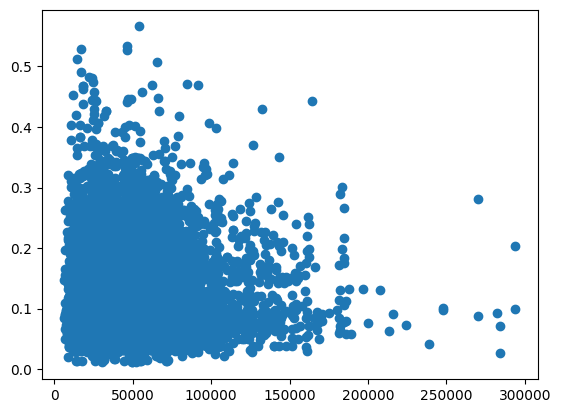

In [17]:
#eda
plt.scatter(train['annual_income'],train['debt_to_income_ratio'])


In [18]:
train.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,11326.000000,11326.000000,11326.000000,11326.000000,11326.000000,11326.000000
mean,5662.500000,48248.089537,0.120325,680.139061,15089.192500,12.368692
std,3269.678909,27409.043916,0.068393,55.084393,6863.501139,2.001831
min,0.000000,6332.300000,0.011000,467.000000,515.060000,4.010000
25%,2831.250000,27484.295000,0.072000,646.000000,10391.880000,10.990000
50%,5662.500000,46247.490000,0.096000,682.500000,15064.550000,12.400000
75%,8493.750000,61348.162500,0.154000,718.000000,18888.410000,13.680000
max,11325.000000,293811.690000,0.566000,848.000000,47865.220000,19.860000


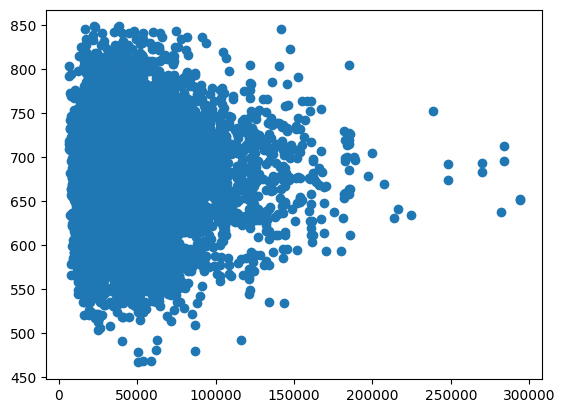

In [19]:
plt.scatter(train['annual_income'],train['credit_score'])

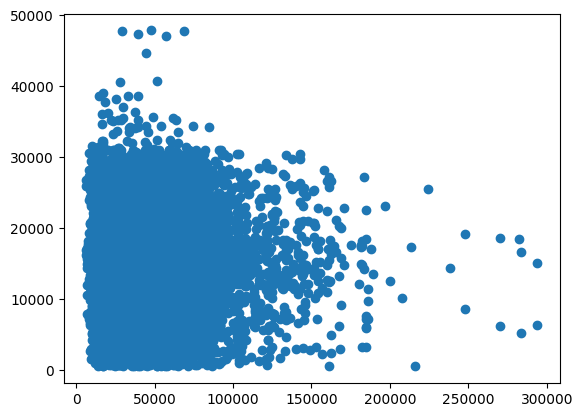

In [20]:
plt.scatter(train['annual_income'],train['loan_amount'])

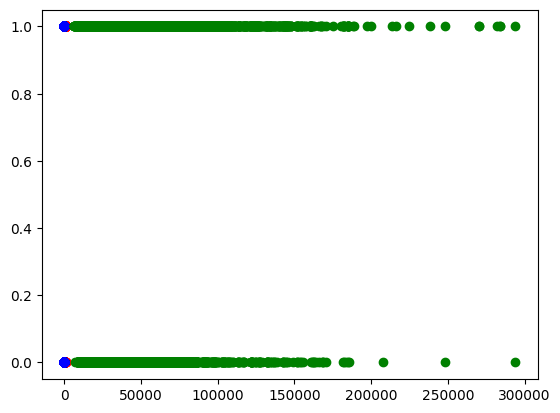

In [21]:
plt.scatter(train['credit_score'],train['loan_paid_back'],color='red')
plt.scatter(train['interest_rate'],train['loan_paid_back'],color='blue')
plt.scatter(train['annual_income'],train['loan_paid_back'],color='green')

In [22]:
train['loan_paid_back'].value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.794014
False,0.205986


In [23]:
train.groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])

annual_income                                   \
                        mean        max     min           std   
loan_paid_back                                                  
False           48152.208538  293811.69  7150.6  27835.872179   
True            48272.963369  293811.69  6332.3  27298.734989   

               debt_to_income_ratio                         credit_score       \
                               mean    max    min       std         mean  max   
loan_paid_back                                                                  
False                      0.163688  0.566  0.014  0.083273   655.044149  829   
True                       0.109075  0.508  0.011  0.058979   686.649283  848   

                                 loan_amount                                 \
                min        std          mean       max     min          std   
loan_paid_back                                                                
False           469  51.527593  15000.671848  47306.53  515.52  6873.635198   
True            467  54.103513  15112.156881  47865.22  515.06  6861.065701   

               interest_rate                         
                        mean    max   min       std  
loan_paid_back                                       
False              12.861264  19.86  6.23  1.963993  
True               12.240907  19.16  4.01  1.991836

In [24]:
pd.crosstab(train['gender'],train['loan_paid_back'])

loan_paid_back,False,True
gender,,
Female,1184,4676
Male,1138,4281
Other,11,36


In [25]:
pd.crosstab(train['gender'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
gender,,
Female,0.507501,0.519960
Male,0.487784,0.476037
Other,0.004715,0.004003


In [26]:
pd.crosstab(train['marital_status'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
marital_status,,
Divorced,0.035148,0.033915
Married,0.465924,0.480596
Single,0.487355,0.475370
Widowed,0.011573,0.010119


In [27]:
pd.crosstab(train['education_level'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
education_level,,
Bachelor's,0.489070,0.457578
High School,0.288041,0.323919
Master's,0.166309,0.158345
Other,0.040720,0.042477
PhD,0.015859,0.017680


In [28]:
pd.crosstab(train['employment_status'],train['loan_paid_back'],normalize='columns')
#seems most relevant out of all features

loan_paid_back,False,True
employment_status,,
Employed,0.413202,0.853108
Retired,0.000000,0.030357
Self-employed,0.045435,0.100300
Student,0.068153,0.007673
Unemployed,0.473210,0.008562


In [29]:
pd.crosstab(train['loan_purpose'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
loan_purpose,,
Business,0.050150,0.062382
Car,0.107587,0.095074
Debt consolidation,0.556365,0.549539
Education,0.065152,0.060158
Home,0.065152,0.075503
Medical,0.037291,0.036250
Other,0.102443,0.106305
Vacation,0.015859,0.014789


In [30]:
pd.crosstab(train['grade_subgrade'],train['loan_paid_back'],normalize='columns')

loan_paid_back,False,True
grade_subgrade,,
A1,0.000000,0.002558
A2,0.000857,0.002891
A3,0.000429,0.002224
A4,0.000000,0.002558
A5,0.000857,0.006005
B1,0.009430,0.027802
B2,0.008144,0.026690
B3,0.008573,0.027358
B4,0.008144,0.026246


In [31]:
train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [32]:
#first doing using train_test_split (for practice)

y=train['loan_paid_back']
dropped_features=['gender', 'marital_status','loan_paid_back','id']
X=train.drop(dropped_features,axis=1)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42,stratify=y)


In [34]:
y_train.value_counts(normalize=True)

,proportion
loan_paid_back,
True,0.794017
False,0.205983


In [35]:
num_cols=['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']
cat_cols=['education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade']

In [36]:
X_train

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level,employment_status,loan_purpose,grade_subgrade
7277,92631.35,0.049,588,13600.02,15.51,High School,Employed,Debt consolidation,E4
9185,29357.27,0.072,673,20402.85,10.14,High School,Employed,Home,C2
11285,56526.68,0.154,596,17704.25,15.71,Other,Employed,Car,E1
1327,52908.12,0.285,708,23198.68,11.76,Bachelor's,Employed,Education,C4
9794,48870.08,0.066,667,20893.20,13.30,Master's,Unemployed,Debt consolidation,D4
...,...,...,...,...,...,...,...,...,...
7979,10057.75,0.173,682,31641.58,12.55,Bachelor's,Unemployed,Home,C1
1464,72593.10,0.195,632,16410.12,12.99,Master's,Unemployed,Home,D5
3543,38468.04,0.096,758,23590.70,10.66,High School,Retired,Home,B5
5809,92667.68,0.087,618,14909.38,11.64,High School,Employed,Medical,D3


In [37]:
#planned work flow:
'''
1. try using train test split then switch to cross validation
2. algos to try:
  1. logistic regression
  2. SVM
  3. DT
  4. Random Forest-> XGboost
'''

'\n1. try using train test split then switch to cross validation\n2. algos to try:\n  1. logistic regression\n  2. SVM\n  3. DT\n  4. Random Forest-> XGboost\n'

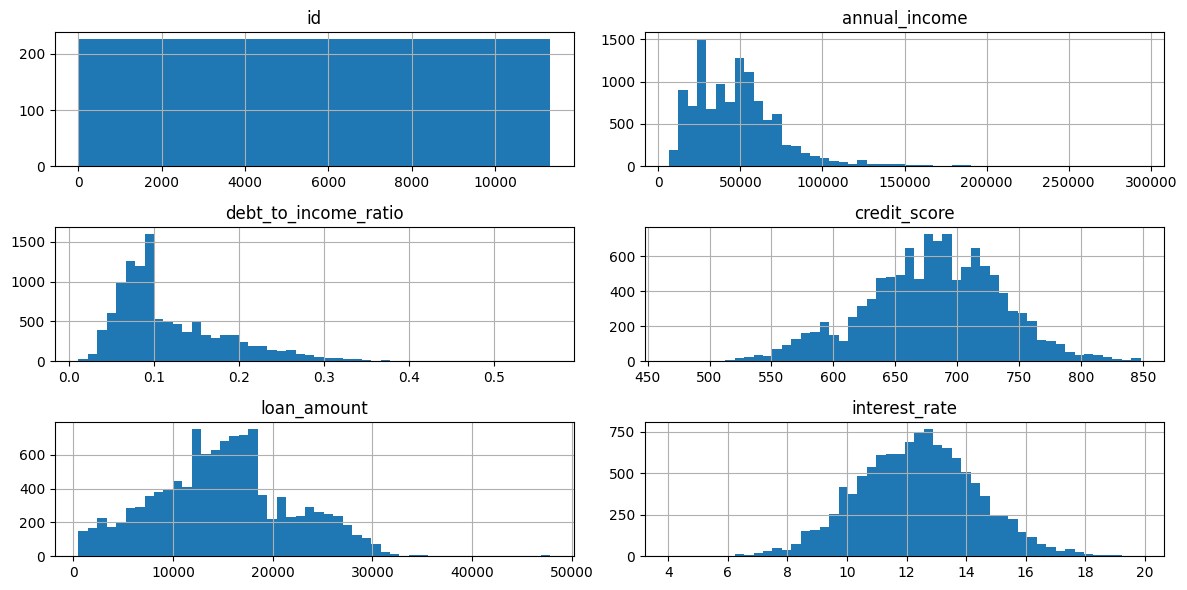

In [38]:
train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

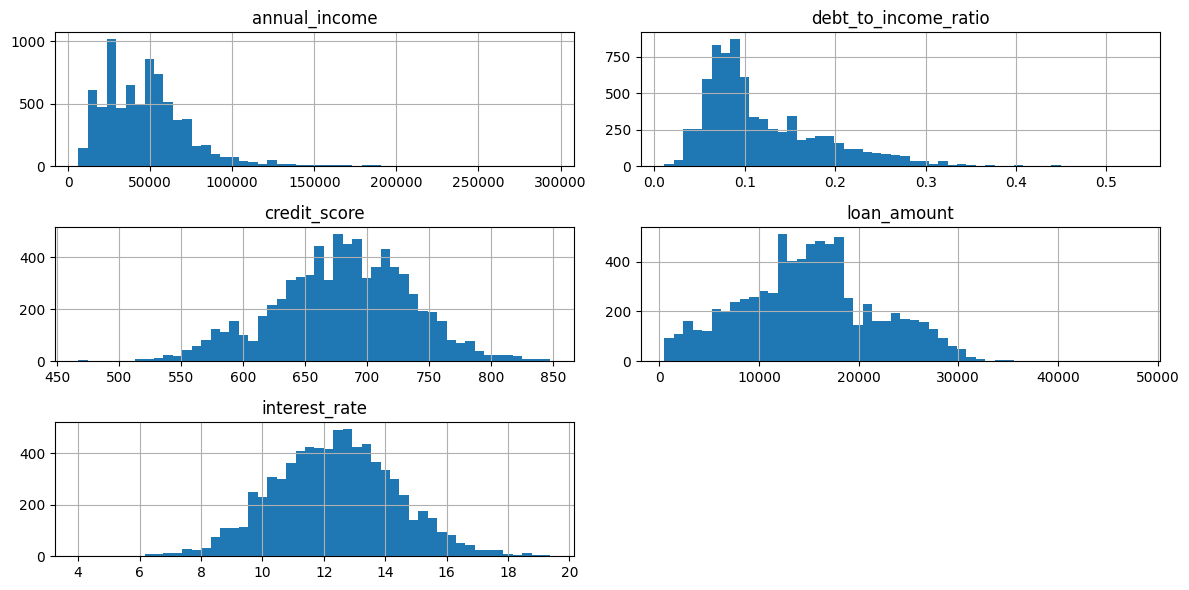

In [39]:
X_train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

In [62]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [48]:
X_train.join(y_train).groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])

annual_income                                \
                        mean       max       min       std   
loan_paid_back                                               
False               0.000507  8.859053 -1.432690  1.042368   
True               -0.000131  8.859053 -1.502003  0.988885   

               debt_to_income_ratio                                \
                               mean       max       min       std   
loan_paid_back                                                      
False                      0.628927  6.038821 -1.472236  1.220591   
True                      -0.163156  5.174976 -1.604009  0.862591   

               credit_score                               loan_amount  \
                       mean       max       min       std        mean   
loan_paid_back                                                          
False             -0.440670  2.703883 -3.833314  0.943831   -0.008319   
True               0.114318  3.048902 -3.869631  0.982439    0.002158   

                                             interest_rate            \
                     max       min       std          mean       max   
loan_paid_back                                                         
False           4.680725 -2.118361  1.011534      0.215073  3.484484   
True            4.761907 -2.118428  0.997143     -0.055794  3.375121   

                                    
                     min       std  
loan_paid_back                      
False          -3.052452  0.988362  
True           -4.156026  0.995599

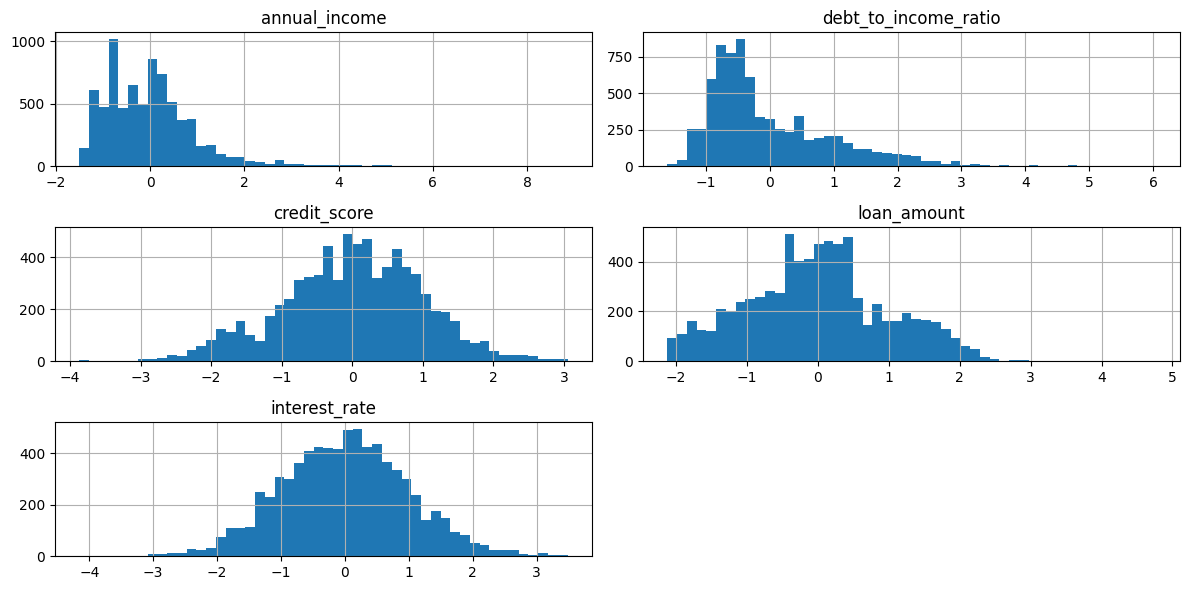

In [49]:
X_train.hist(figsize=(12,6),bins=50)
plt.tight_layout()

In [44]:
#trying the minmaxscaling
'''from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_train.join(y_train).groupby('loan_paid_back')[['annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate']].agg(["mean",'max','min',"std"])
'''

annual_income                         debt_to_income_ratio  \
                        mean  max      min       std                 mean   
loan_paid_back                                                              
False               0.145015  1.0  0.00669  0.100604             0.292161   
True                0.144954  1.0  0.00000  0.095443             0.188524   

                                             credit_score                      \
                     max       min       std         mean       max       min   
loan_paid_back                                                                  
False           1.000000  0.017241  0.159704     0.495620  0.950131  0.005249   
True            0.886973  0.000000  0.112863     0.575837  1.000000  0.000000   

                         loan_amount                               \
                     std        mean       max      min       std   
loan_paid_back                                                      
False           0.136421    0.306687  0.988201  0.00001  0.147018   
True            0.142001    0.308210  1.000000  0.00000  0.144926   

               interest_rate                                
                        mean       max       min       std  
loan_paid_back                                              
False               0.572095  1.000000  0.144437  0.129358  
True                0.536644  0.985686  0.000000  0.130305

In [58]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

encoded_values=encoder.fit_transform(X_train[cat_cols])
new_cols=encoder.get_feature_names_out(cat_cols)

(7588, 48)

In [60]:
encoded_df=pd.DataFrame(encoded_values,columns=new_cols,index=X_train.index)

prep_X_train=pd.concat([X_train.drop(columns=cat_cols),encoded_df],axis=1)
prep_X_train

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
7277,1.608304,-1.047635,-1.672407,-0.217085,1.560686,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9185,-0.672160,-0.710882,-0.128902,0.771417,-1.108770,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11285,0.307054,0.489716,-1.527136,0.379290,1.660107,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1327,0.176638,2.407745,0.506659,1.177673,-0.303459,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9794,0.031102,-0.798730,-0.237855,0.842669,0.462083,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7979,-1.367734,0.767904,0.034528,2.404489,0.089254,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1464,0.886105,1.090015,-0.873416,0.191244,0.307981,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3543,-0.343798,-0.359487,1.414603,1.234636,-0.850275,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5809,1.609613,-0.491260,-1.127641,-0.026825,-0.363112,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
#first using logistic regression

from sklearn.linear_model import LogisticRegression

LogReg=LogisticRegression()
LogReg.fit(prep_X_train,y_train)

LogisticRegression()